In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, root_mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline

In [25]:
np.random.seed(42)
# Generate synthetic data
new_hours = np.random.rand(25) * 35 
new_marks = (new_hours * 2.5) + (np.random.randn(25) * 5)  #Created random marks with some noise
new_marks = np.clip(new_marks, 0, 100)  #I ensured marks are between 0 and 100
timescore_data = pd.DataFrame({'Hours_of_Study': new_hours.round(0), 'Test_Score': new_marks.round(2)})
timescore_data

,Hours_of_Study,Test_Score
0,13.0,29.62
1,33.0,86.18
2,26.0,76.85
3,21.0,54.35
4,5.0,14.26
5,5.0,11.07
6,2.0,2.08
7,30.0,80.53
8,21.0,54.05
9,25.0,58.78


In [26]:
# Load new user details like Name, Email,Phone_Number from CSV
new_users_data = pd.read_csv('New_users_details.csv')
Student_IDs = []
Index_num = 25
for Name, Email, Phone_Number in zip(new_users_data['Name'], new_users_data['Email Address'], new_users_data['Phone Number']):
    #print(f'{Index_num}, {Name}, {Email}, {Phone_Number}')
    Index_num += 1
    Student_IDs.append(Index_num)

#Below is a left join on student ID to add new user details to the new test score data
#new_data_extended = pd.merge(timescore_data, new_users_data, how='left')
#df_extended = pd.concat([new_users_data, timescore_data], ignore_index=True)
#df_extended = pd.merge(new_users_data, timescore_data, on='Student_ID', how='left')
df_studentID = pd.DataFrame({'Student_ID': Student_IDs})
df_extended = pd.concat([df_studentID, new_users_data,timescore_data], axis=1)
df_extended.head(10)

,Student_ID,Name,Email Address,Phone Number,Hours_of_Study,Test_Score
0,26,Jackson Scott,jackson.scott28@data-ml.org,(555) 987-0123,13.0,29.62
1,27,Grace Rogers,grace.rogers17@data-ml.org,(555) 321-4567,33.0,86.18
2,28,Lucas Cook,lucas.cook06@data-ml.org,(555) 654-7890,26.0,76.85
3,29,Lily Clark,lily.clark95@data-ml.org,(555) 789-3210,21.0,54.35
4,30,Aiden Torres,aiden.torres83@data-ml.org,(555) 123-6540,5.0,14.26
5,31,Zoe Flores,zoe.flores72@data-ml.org,(555) 456-9870,5.0,11.07
6,32,Gabriel Hill,gabriel.hill61@data-ml.org,(555) 890-3456,2.0,2.08
7,33,Aria Rivera,aria.rivera50@data-ml.org,(555) 234-7654,30.0,80.53
8,34,Elijah Cooper,elijah.cooper41@data-ml.org,(555) 567-0123,21.0,54.05
9,35,Hannah Evans,hannah.evans30@data-ml.org,(555) 901-4321,25.0,58.78


In [27]:
dfvOne = pd.read_csv('Test_Score_Prediction_Data.csv')
print("First five rows of the CSV dataset:")
dfvOne.head()

First five rows of the CSV dataset:


,Student_ID,Name,Email Address,Phone Number,Hours_of_Study,Test_Score
0,1,Maya Sharma,maya.sharma99@data-ml.org,(555) 123-4567,2.5,61
1,2,Ethan Bell,ethan.bell01@data-ml.org,(555) 987-6543,3.0,52
2,3,Chloe Wong,chloe.wong88@data-ml.org,(555) 321-7890,5.5,63
3,4,Liam Miller,liam.miller76@data-ml.org,(555) 654-3210,6.5,57
4,5,Ava Garcia,ava.garcia55@data-ml.org,(555) 789-0123,7.0,62


In [28]:
print(f'Dataset Information:\n{dfvOne.info()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      25 non-null     int64  
 1   Name            25 non-null     object 
 2   Email Address   25 non-null     object 
 3   Phone Number    25 non-null     object 
 4   Hours_of_Study  25 non-null     float64
 5   Test_Score      25 non-null     int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 1.3+ KB
Dataset Information:
None


In [29]:
print(f'\n Test_Score_Prediction_Data.csv Dataset Statistics:\n{'==' * 22}\n{dfvOne.describe()} \nDataset shape: {dfvOne.shape} \n')


 Test_Score_Prediction_Data.csv Dataset Statistics:
       Student_ID  Hours_of_Study  Test_Score
count   25.000000       25.000000    25.00000
mean    13.000000       16.620000    73.36000
std      7.359801        8.823831    13.80483
min      1.000000        2.500000    44.00000
25%      7.000000       10.000000    61.00000
50%     13.000000       16.000000    76.00000
75%     19.000000       24.000000    87.00000
max     25.000000       31.000000    90.00000 
Dataset shape: (25, 6) 



We generated a new table made up of random numbers for Hours_of_Study(0-35), and Test_Score(0-100). This is heavily impact the Mean Square Error to evaluate model performance, when we increase the amount of data we train our model on the lesser the MSE becomes.

In [30]:
#Generate an new table entirely
df_final = pd.concat([dfvOne, df_extended], ignore_index=True)
df_final.to_csv("New_Test_Score_Data.csv", index=False)
df_final.dropna(inplace=True)
df_final.tail()

,Student_ID,Name,Email Address,Phone Number,Hours_of_Study,Test_Score
45,46,Nathan Foster,nathan.foster27@data-ml.org,(555) 901-5678,21.0,54.63
46,47,Madison Jenkins,madison.jenkins16@data-ml.org,(555) 234-8901,5.0,16.61
47,48,Jayden Perry,jayden.perry05@data-ml.org,(555) 567-1234,10.0,20.52
48,49,Aurora Russell,aurora.russell94@data-ml.org,(555) 890-4567,13.0,24.14
49,50,Wyatt Brooks,wyatt.brooks82@data-ml.org,(555) 109-8765,16.0,43.77


In [31]:
#Using NumPy for Statistical Analysis
mean_mark = np.average(df_final['Test_Score'])
median_mark = np.median(df_final['Test_Score'])
max_mark = np.max(df_final['Test_Score'])
min_mark = np.min(df_final['Test_Score'])
range_mark = max_mark - min_mark
pass_rate = np.sum(df_final['Test_Score'] >= 50) / len(df_final) * 100
pass_mark = 75

In [32]:
#Function to round scores to 2 decimal places
def rounder(score):
    test_score = score.round(2)
    return test_score

In [33]:
print(f'Mean Test Score: {rounder(mean_mark)}%')
print(f'Median Test Score: {rounder(median_mark)}%')
print(f'Max Test Score: {rounder(max_mark)}%')
print(f'Min Test Score: {rounder(min_mark)}%')
print(f'Range of Test Scores: {rounder(range_mark)}%')
print(f'Exam Pass Rate: {rounder(pass_rate)}% \n')

Mean Test Score: 56.44%
Median Test Score: 60.0%
Max Test Score: 90.0%
Min Test Score: 0.0%
Range of Test Scores: 90.0%
Exam Pass Rate: 70.0% 



In [34]:
#Passed students
passed_students= df_final[df_final['Test_Score'] >= pass_mark]
students_above_pass_rate = df_final[df_final['Test_Score'] >= pass_rate]
print(f'Number of students above the Pass Score: {len(passed_students)} \nNumber of students who Passed Exam: {len(students_above_pass_rate)}')
print(f'{"==" * 20}')
failed_student = df_final[df_final['Test_Score'] < pass_mark]
students_below_pass_rate = df_final[df_final['Test_Score'] < pass_rate ]
exam_top_scorers = df_final[df_final['Test_Score'] >= 85]
print(f'Number of students below the Pass Score: {len(failed_student)} \nNumber of students who Failed Exam: {len(students_below_pass_rate)}')
print(f'Number of Top Scorers in Exam: {len(exam_top_scorers)}')

Number of students above the Pass Score: 18 
Number of students who Passed Exam: 20
Number of students below the Pass Score: 32 
Number of students who Failed Exam: 30
Number of Top Scorers in Exam: 9


In [35]:
Mean_value = passed_students['Test_Score'].mean()
max_value = passed_students['Test_Score'].max()
min_value = passed_students['Test_Score'].min()
print(f'Maximum Test Score of Passed Students: {rounder(max_value)}%')
print(f'Minimum Test Score of Passed Students: {rounder(min_value)}%')
print(f'Average Test Score of Passed Students: {rounder(Mean_value)}%')
passed_students.sort_values(by='Test_Score', ascending=False)
print(f"Class exam pass rate: {len(passed_students)/len(df_final)*100}%")


Maximum Test Score of Passed Students: 90.0%
Minimum Test Score of Passed Students: 75.0%
Average Test Score of Passed Students: 83.48%
Class exam pass rate: 36.0%


In [36]:
Mean_value = failed_student['Test_Score'].mean()
max_value = failed_student['Test_Score'].max()
min_value = failed_student['Test_Score'].min()
print(f'Maximum Test Score of Failed Students: {rounder(max_value)}%')
print(f'Minimum Test Score of Failed Students: {rounder(min_value)}%')
print(f'Average Test Score of Failed Students: {rounder(Mean_value)}%')
failed_student.sort_values(by='Test_Score', ascending=True)


Maximum Test Score of Failed Students: 74.0%
Minimum Test Score of Failed Students: 0.0%
Average Test Score of Failed Students: 41.22%


,Student_ID,Name,Email Address,Phone Number,Hours_of_Study,Test_Score
35,36,Samuel Reed,samuel.reed29@data-ml.org,(555) 012-7890,1.0,0.00
31,32,Gabriel Hill,gabriel.hill61@data-ml.org,(555) 890-3456,2.0,2.08
30,31,Zoe Flores,zoe.flores72@data-ml.org,(555) 456-9870,5.0,11.07
29,30,Aiden Torres,aiden.torres83@data-ml.org,(555) 123-6540,5.0,14.26
39,40,Asher Murphy,asher.murphy85@data-ml.org,(555) 123-9876,6.0,14.76
46,47,Madison Jenkins,madison.jenkins16@data-ml.org,(555) 234-8901,5.0,16.61
40,41,Luna Bailey,luna.bailey74@data-ml.org,(555) 456-1098,6.0,17.99
38,39,Victoria Wood,victoria.wood96@data-ml.org,(555) 901-6543,7.0,18.55
41,42,Caleb Hughes,caleb.hughes63@data-ml.org,(555) 789-4321,11.0,20.30
47,48,Jayden Perry,jayden.perry05@data-ml.org,(555) 567-1234,10.0,20.52


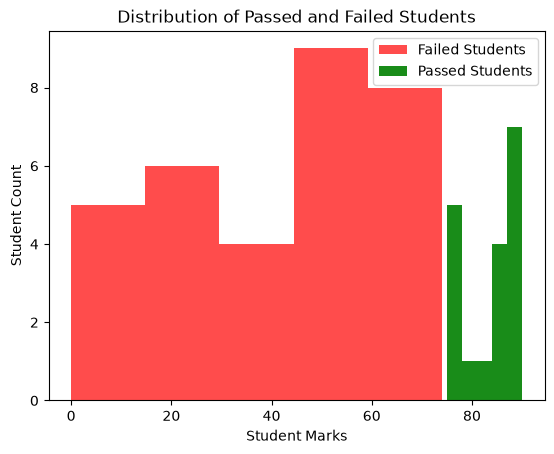

In [37]:
plt.hist(failed_student['Test_Score'], bins=5, color='red', alpha=0.7, label='Failed Students')
plt.hist(passed_students['Test_Score'], bins=5, color='green', alpha=0.9, label='Passed Students')
plt.title('Distribution of Passed and Failed Students')
plt.xlabel('Student Marks')
plt.ylabel('Student Count')
plt.legend()
plt.show()

In [38]:
#New_Test_Score_Data.csv table stats
print(f'New_Test_Score_Data.csv Stats: \n{'==' * 22}\n {df_final.describe().round(2)}.')

New_Test_Score_Data.csv Stats: 
        Student_ID  Hours_of_Study  Test_Score
count       50.00           50.00       50.00
mean        25.50           15.97       56.44
std         14.58            9.36       27.10
min          1.00            1.00        0.00
25%         13.25            7.25       34.53
50%         25.50           15.00       60.00
75%         37.75           23.50       79.65
max         50.00           34.00       90.00.


Feature shape: (50, 1), Target shape: (50,)


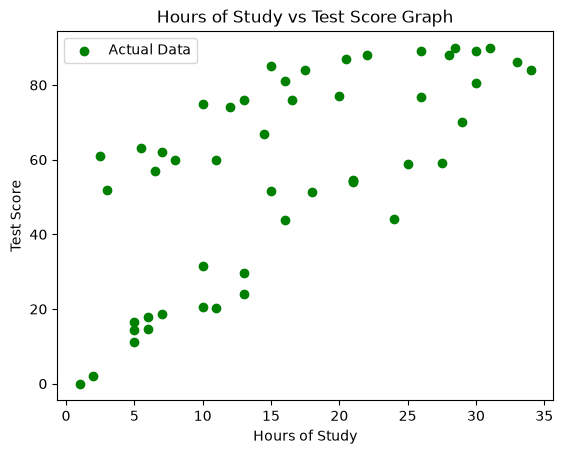

In [39]:
X = df_final[['Hours_of_Study']].values
y = df_final['Test_Score'].values
print(f'Feature shape: {X.shape}, Target shape: {y.shape}')

plt.scatter(X,y,color='green',label='Actual Data') #alpha is used for transparency
plt.title('Hours of Study vs Test Score Graph')
plt.xlabel('Hours of Study')
plt.ylabel('Test Score')
plt.legend()
plt.show()

In [40]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(f'Training feature shape: {X_train.shape} \nTraining target shape: {y_train.shape}')

Training feature shape: (40, 1) 
Training target shape: (40,)


Hours of studying: [16.5  6.   5.  21.  22.  13.  33.  13.  30.  26. ]
Predicted Test Scores: [58.83 39.8  37.98 66.98 68.79 52.48 88.73 52.48 83.29 76.04]


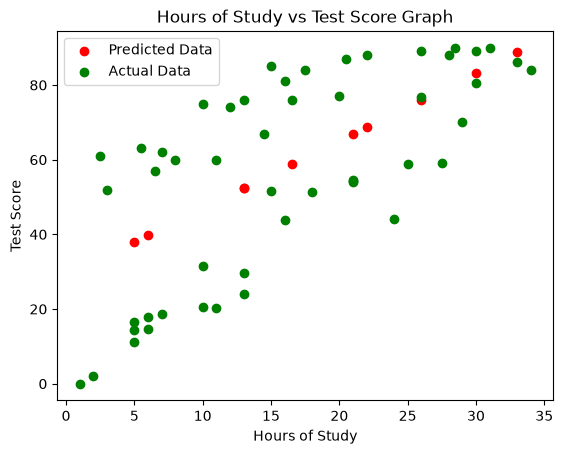

In [41]:
model = LinearRegression()
model.fit(X_train,y_train) # Training the model on the training set
y_pred = model.predict(X_test) # Predicting test scores for the test set
print(f'Hours of studying: {X_test.flatten()}\nPredicted Test Scores: {y_pred.round(2)}')
plt.scatter(X_test.flatten(),y_pred.round(2),color='red',label='Predicted Data')
plt.scatter(X,y,color='green',label='Actual Data') #alpha is used for transparency
#plt.plot(X_test,y_pred,color='red',linewidth=2,label='Regression Line')
plt.title('Hours of Study vs Test Score Graph')
plt.xlabel('Hours of Study')
plt.ylabel('Test Score')
plt.legend()
plt.show()

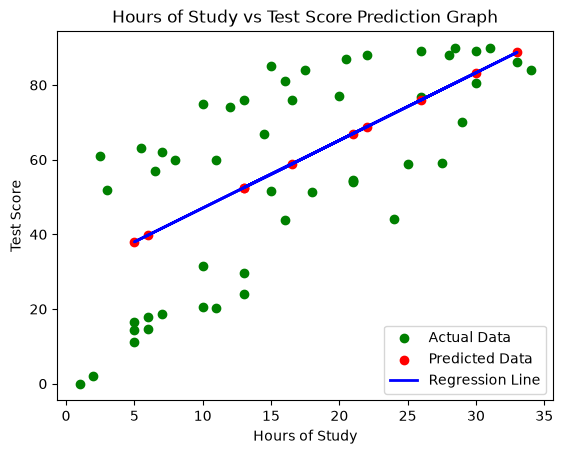

In [42]:
plt.scatter(X,y,color='green',label='Actual Data') #alpha is used for transparency
plt.scatter(X_test.flatten(),y_pred.round(2),color='red',label='Predicted Data')
plt.plot(X_test,y_pred,color='blue',linewidth=2,label='Regression Line')
plt.title('Hours of Study vs Test Score Prediction Graph')
plt.xlabel('Hours of Study')
plt.ylabel('Test Score')
plt.legend()
plt.show()

In [ ]:
mse = mean_squared_error(y_test,y_pred) #lets calculate the Mean Squared Error for model evaluation
r2 = r2_score(y_test,y_pred) #Calculating R^2 Score for model evaluation
accuracy_score  = model.score(X_test, y_test) 
rmse = root_mean_squared_error(y_test,y_pred)
print(f'Mean Squared Error: {mse.__round__(2)}')
print(f'R^2 Score: {r2.__round__(2)}')
#lets see our models accuracy score for its evaluation
print(f'Accuracy Score: {accuracy_score.__round__(2)}')
print(f'RMSE: {rmse}')

Mean Squared Error: 367.55
R^2 Score: 0.61
Accuracy Score: 0.61
RMSE: 19.171693623640074
